In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import torch
from sentence_transformers import SentenceTransformer

In [ ]:
GH_DATA_DIR = Path("/content/drive/MyDrive/ghdata")
POSTMORTEM_DIR = Path("/content/drive/MyDrive/postmortems")
OUTPUT_DIR = Path("/content/drive/MyDrive/postmortem_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = GH_DATA_DIR / "github_issue_pr_features.csv"
RAW_PATH = GH_DATA_DIR / "github_issue_pr_raw.csv"
SUMMARY_PATH = GH_DATA_DIR / "github_repo_collection_summary.csv"

print("features exists:", FEATURES_PATH.exists(), FEATURES_PATH)
print("raw exists:", RAW_PATH.exists(), RAW_PATH)
print("summary exists:", SUMMARY_PATH.exists(), SUMMARY_PATH)
print("postmortem dir exists:", POSTMORTEM_DIR.exists(), POSTMORTEM_DIR)

features exists: True /content/drive/MyDrive/ghdata/github_issue_pr_features.csv
raw exists: True /content/drive/MyDrive/ghdata/github_issue_pr_raw.csv
summary exists: True /content/drive/MyDrive/ghdata/github_repo_collection_summary.csv
postmortem dir exists: True /content/drive/MyDrive/postmortems


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
features = pd.read_csv(FEATURES_PATH)
raw = pd.read_csv(RAW_PATH)
summary = pd.read_csv(SUMMARY_PATH)

print("features:", features.shape)
print("raw:", raw.shape)
print("summary:", summary.shape)

print(features.columns.tolist())
display(features.head())

features: (248, 38)
raw: (248, 25)
summary: (8, 7)
['repo', 'issue_number', 'issue_title', 'issue_body', 'issue_labels', 'issue_created_at', 'issue_closed_at', 'issue_comments_count', 'issue_url', 'pr_number', 'pr_title', 'pr_body', 'pr_created_at', 'pr_merged_at', 'pr_comments_count', 'pr_review_comments_count', 'pr_url', 'merge_commit_sha', 'files_changed', 'num_files_changed', 'additions', 'deletions', 'total_loc_changed', 'linked_pr_match_count', 'linked_pr_numbers', 'issue_text', 'pr_text', 'combined_text', 'high_severity_words', 'low_severity_words', 'narrative_severity_score', 'sensitive_file_count', 'log_total_loc_changed', 'log_num_files_changed', 'technical_risk_score', 'drift_score', 'security_relevant_v1', 'drift_quartile']


,repo,issue_number,issue_title,issue_body,issue_labels,issue_created_at,issue_closed_at,issue_comments_count,issue_url,pr_number,...,high_severity_words,low_severity_words,narrative_severity_score,sensitive_file_count,log_total_loc_changed,log_num_files_changed,technical_risk_score,drift_score,security_relevant_v1,drift_quartile
0,python/cpython,149122,Segfault with async generator expressions,# Crash report\n\n### What happened?\n\nRunnin...,"['interpreter-core', 'type-crash', '3.14', '3....",2026-04-29T00:33:38Z,2026-04-29T13:35:53Z,2,https://github.com/python/cpython/issues/149122,149138,...,3,1,2,0,3.496508,1.386294,-0.844590,-1.850236,1,Q1 lowest drift
1,python/cpython,144538,Update bundled pip to 26.0.1,Python 3.10's bundled pip (23.0.1) and setupto...,"['type-feature', 'stdlib', 'topic-ensurepip', ...",2026-02-06T10:07:06Z,2026-02-07T12:27:48Z,18,https://github.com/python/cpython/issues/144538,144556,...,3,2,1,0,1.386294,1.386294,-1.962098,-1.653056,1,Q1 lowest drift
2,python/cpython,135528,Support more second-level domain names in http...,# Feature or enhancement\n\n### Proposal:\n\ni...,"['type-feature', 'stdlib']",2025-06-15T03:30:53Z,2026-04-29T12:38:14Z,1,https://github.com/python/cpython/issues/135528,135820,...,0,1,-1,1,2.564949,1.098612,-1.064876,0.068062,1,Q3
3,python/cpython,133346,Theming support for _colorize,"As mentioned in #131507 and #130645, theming s...","['type-feature', 'stdlib']",2025-05-03T15:12:13Z,2025-05-21T10:36:12Z,2,https://github.com/python/cpython/issues/133346,133347,...,2,1,1,0,6.855409,3.044522,2.645564,0.298665,1,Q3
4,python/cpython,140287,The asyncio REPL interactive daemon thread doe...,# Bug report\n\n### Bug description:\n\nThat l...,"['type-bug', 'topic-asyncio', 'stdlib', '3.13'...",2025-10-18T09:57:08Z,2026-04-29T09:57:29Z,4,https://github.com/python/cpython/issues/140287,140288,...,1,3,-2,0,4.060443,1.386294,-0.545946,0.958408,0,Q4 highest drift




```
bottom 25% = low drift
top 25% = high drift
middle 50% = not used for training, but still scored later
```



In [ ]:
!pip install -q sentence-transformers

In [ ]:
required_cols = ["drift_score", "combined_text"]

missing = [c for c in required_cols if c not in features.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

q25 = features["drift_score"].quantile(0.25)
q75 = features["drift_score"].quantile(0.75)

def assign_drift_bucket(score):
    if score <= q25:
        return "low_drift"
    elif score >= q75:
        return "high_drift"
    else:
        return "middle"

features["phase3_drift_bucket"] = features["drift_score"].apply(assign_drift_bucket)

print("Q25 low-drift threshold:", q25)
print("Q75 high-drift threshold:", q75)
print(features["phase3_drift_bucket"].value_counts())

Q25 low-drift threshold: -0.8939286245863356
Q75 high-drift threshold: 0.759187277429116
phase3_drift_bucket
middle        124
low_drift      62
high_drift     62
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"`{1,3}.*?`{1,3}", " ", text, flags=re.S)
    text = re.sub(r"\b[0-9a-f]{7,40}\b", " ", text)
    text = re.sub(r"#[0-9]+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[_\-=/\\]+", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()

features["clean_text"] = features["combined_text"].fillna("").apply(clean_text)

high_df = features[features["phase3_drift_bucket"] == "high_drift"].copy()
low_df = features[features["phase3_drift_bucket"] == "low_drift"].copy()
training_df = features[features["phase3_drift_bucket"].isin(["high_drift", "low_drift"])].copy()

print("High drift rows:", len(high_df))
print("Low drift rows:", len(low_df))
print("Training rows:", len(training_df))

High drift rows: 62
Low drift rows: 62
Training rows: 124


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    min_df=2,
    max_features=8000
)

X_tfidf = vectorizer.fit_transform(training_df["clean_text"])
terms = np.array(vectorizer.get_feature_names_out())

high_mask = training_df["phase3_drift_bucket"].values == "high_drift"
low_mask = training_df["phase3_drift_bucket"].values == "low_drift"

high_mean = np.asarray(X_tfidf[high_mask].mean(axis=0)).ravel()
low_mean = np.asarray(X_tfidf[low_mask].mean(axis=0)).ravel()

wording_scores = pd.DataFrame({
    "term": terms,
    "high_drift_tfidf": high_mean,
    "low_drift_tfidf": low_mean,
})

wording_scores["high_minus_low"] = (
    wording_scores["high_drift_tfidf"] - wording_scores["low_drift_tfidf"]
)

high_wording = wording_scores.sort_values("high_minus_low", ascending=False).head(50)
low_wording = wording_scores.sort_values("high_minus_low", ascending=True).head(50)

display(high_wording)
display(low_wording)

wording_scores.to_csv(OUTPUT_DIR / "phase3_wording_scores.csv", index=False)
high_wording.to_csv(OUTPUT_DIR / "phase3_high_drift_wording.csv", index=False)
low_wording.to_csv(OUTPUT_DIR / "phase3_low_drift_wording.csv", index=False)

,term,high_drift_tfidf,low_drift_tfidf,high_minus_low
1454,gh,0.140930,0.079184,0.061745
2643,preview,0.033286,0.000000,0.033286
2584,pr,0.051838,0.022701,0.029137
2354,number,0.045983,0.019512,0.026472
2725,prs,0.045890,0.021179,0.024711
3577,title,0.029738,0.006640,0.023098
1781,issue number,0.040032,0.017397,0.022634
1263,feature,0.026521,0.004008,0.022513
2826,readthedocs preview,0.022191,0.000000,0.022191
2648,previews,0.022191,0.000000,0.022191


,term,high_drift_tfidf,low_drift_tfidf,high_minus_low
2779,rails,0.000553,0.025554,-0.025001
3119,ruby,0.000553,0.019049,-0.018496
1318,fix,0.005153,0.023007,-0.017854
654,const,0.002109,0.018635,-0.016526
2351,null,0.000725,0.015498,-0.014773
175,ares,0.000000,0.014574,-0.014574
447,cfg,0.002380,0.016715,-0.014336
3382,storage,0.000472,0.014124,-0.013653
188,arm,0.000645,0.014253,-0.013608
3827,version,0.011218,0.024026,-0.012807


In [ ]:
def cluster_text_rows(df, text_col="clean_text", n_clusters=5, label="cluster"):
    df = df.copy()

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 3),
        min_df=2,
        max_features=5000
    )

    X = vec.fit_transform(df[text_col])
    terms = np.array(vec.get_feature_names_out())

    n_clusters = min(n_clusters, len(df))

    km = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init="auto"
    )

    clusters = km.fit_predict(X)
    df[label] = clusters

    cluster_terms = []
    centers = km.cluster_centers_

    for c in range(n_clusters):
        top_idx = centers[c].argsort()[::-1][:15]
        top_terms = terms[top_idx].tolist()

        cluster_terms.append({
            label: c,
            "row_count": int((clusters == c).sum()),
            "top_terms": ", ".join(top_terms)
        })

    return df, pd.DataFrame(cluster_terms)

high_clustered, high_cluster_terms = cluster_text_rows(
    high_df,
    n_clusters=5,
    label="high_drift_cluster"
)

low_clustered, low_cluster_terms = cluster_text_rows(
    low_df,
    n_clusters=5,
    label="low_drift_cluster"
)

display(high_cluster_terms)
display(low_cluster_terms)

high_clustered.to_csv(OUTPUT_DIR / "phase3_high_drift_clustered_rows.csv", index=False)
low_clustered.to_csv(OUTPUT_DIR / "phase3_low_drift_clustered_rows.csv", index=False)
high_cluster_terms.to_csv(OUTPUT_DIR / "phase3_high_drift_cluster_terms.csv", index=False)
low_cluster_terms.to_csv(OUTPUT_DIR / "phase3_low_drift_cluster_terms.csv", index=False)

,high_drift_cluster,row_count,top_terms
0,0,14,"gh, number, issue, prs, title, issue number, g..."
1,1,6,"triagebot, rust, let, exceptions, case, order,..."
2,2,10,"gh, gh gh, gh gh gh, linked prs, gh issue, prs..."
3,3,25,"kind, pr, details, api, license, windows, dns,..."
4,4,7,"workspace, riscv, backtrace, build, rust, comp..."


,low_drift_cluster,row_count,top_terms
0,0,14,"node, ares, dns, behavior, license, node js, l..."
1,1,11,"rust, rust lang rust, rust lang, lang rust, la..."
2,2,14,"gh, gh gh, gh issue, prs, linked prs, linked, ..."
3,3,2,"ruby, details, rb, home, lib, details details,..."
4,4,21,"rails, request, vs, test, workbench, storage, ..."


In [ ]:
MODEL_NAME = "BAAI/bge-base-en-v1.5"

embedder = SentenceTransformer(MODEL_NAME, device=device)

print("Loaded model:", MODEL_NAME)
print("Model device:", embedder.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded model: BAAI/bge-base-en-v1.5
Model device: cuda:0


In [ ]:
training_df = features[features["phase3_drift_bucket"].isin(["high_drift", "low_drift"])].copy()

training_df["binary_label"] = training_df["phase3_drift_bucket"].map({
    "low_drift": 0,
    "high_drift": 1
})

train_texts = training_df["combined_text"].fillna("").astype(str).tolist()
y = training_df["binary_label"].values

batch_size = 16 if device == "cuda" else 8

train_embeddings = embedder.encode(
    train_texts,
    show_progress_bar=True,
    normalize_embeddings=True,
    batch_size=batch_size
)

print("Train embeddings shape:", train_embeddings.shape)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Train embeddings shape: (124, 768)


In [ ]:
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    train_embeddings,
    y,
    training_df.index.values,
    test_size=0.25,
    random_state=42,
    stratify=y
)

clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

test_pred = clf.predict(X_test)
test_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    test_pred,
    target_names=["low_drift", "high_drift"]
))

print("ROC AUC:", roc_auc_score(y_test, test_proba))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred))

              precision    recall  f1-score   support

   low_drift       0.79      0.69      0.73        16
  high_drift       0.71      0.80      0.75        15

    accuracy                           0.74        31
   macro avg       0.75      0.74      0.74        31
weighted avg       0.75      0.74      0.74        31

ROC AUC: 0.8083333333333333
Confusion matrix:
[[11  5]
 [ 3 12]]


In [ ]:
all_github_texts = features["combined_text"].fillna("").astype(str).tolist()

all_github_embeddings = embedder.encode(
    all_github_texts,
    show_progress_bar=True,
    normalize_embeddings=True,
    batch_size=batch_size
)

features["semantic_high_drift_probability"] = clf.predict_proba(all_github_embeddings)[:, 1]

features["semantic_predicted_bucket"] = np.where(
    features["semantic_high_drift_probability"] >= 0.5,
    "potential_high_drift",
    "potential_low_drift"
)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
comparison_cols = [
    "drift_score",
    "phase3_drift_bucket",
    "semantic_high_drift_probability",
    "semantic_predicted_bucket",
    "combined_text"
]

optional_cols = [
    "repo",
    "issue_number",
    "pr_number",
    "issue_title",
    "pr_title",
    "issue_url",
    "pr_url",
    "drift_quartile"
]

comparison_cols = [c for c in optional_cols + comparison_cols if c in features.columns]

github_comparison = features[comparison_cols].copy()

github_comparison.to_csv(
    OUTPUT_DIR / "phase3_semantic_model_vs_github_drift_score.csv",
    index=False
)

display(
    github_comparison
    .sort_values("semantic_high_drift_probability", ascending=False)
    .head(20)
)

display(
    github_comparison
    .sort_values("semantic_high_drift_probability", ascending=True)
    .head(20)
)

,repo,issue_number,pr_number,issue_title,pr_title,issue_url,pr_url,drift_quartile,drift_score,phase3_drift_bucket,semantic_high_drift_probability,semantic_predicted_bucket,combined_text
23,python/cpython,148588,148590,Document `__lazy_modules__`,gh-148588: Document `__lazy_modules__`,https://github.com/python/cpython/issues/148588,https://github.com/python/cpython/pull/148590,Q4 highest drift,2.474704,high_drift,0.681075,potential_high_drift,Document `__lazy_modules__` ### Documentation\...
22,python/cpython,148991,148992,Add colour to `tokenize` CLI output,gh-148991: Add colour to `tokenize` CLI output,https://github.com/python/cpython/issues/148991,https://github.com/python/cpython/pull/148992,Q4 highest drift,3.386031,high_drift,0.661640,potential_high_drift,Add colour to `tokenize` CLI output # Feature ...
49,python/cpython,148207,148212,add variance support to `TypeVarTuple`,gh-148207: add additional keywords to `typing....,https://github.com/python/cpython/issues/148207,https://github.com/python/cpython/pull/148212,Q4 highest drift,2.214385,high_drift,0.658353,potential_high_drift,add variance support to `TypeVarTuple` # Featu...
48,python/cpython,148892,148893,Docs: free-threaded extension guide refers to ...,gh-148892: Drop mention of deprecated cibuildw...,https://github.com/python/cpython/issues/148892,https://github.com/python/cpython/pull/148893,Q4 highest drift,0.907978,high_drift,0.657959,potential_high_drift,Docs: free-threaded extension guide refers to ...
21,python/cpython,108951,123837,Add an `asyncio.TaskGroup.cancel` method,gh-108951: document how to terminate an `async...,https://github.com/python/cpython/issues/108951,https://github.com/python/cpython/pull/123837,Q4 highest drift,1.954015,high_drift,0.642724,potential_high_drift,Add an `asyncio.TaskGroup.cancel` method # Fea...
9,python/cpython,107956,108033,Install a static installation description file...,Improve the feature-proposal issue form,https://github.com/python/cpython/issues/107956,https://github.com/python/cpython/pull/108033,Q2,-0.893160,middle,0.641668,potential_high_drift,Install a static installation description file...
53,python/cpython,148186,148463,"Docs: problem with page ""unittest — Unit testi...",gh-148186: Improve `assertCountEqual` descript...,https://github.com/python/cpython/issues/148186,https://github.com/python/cpython/pull/148463,Q4 highest drift,0.851604,high_drift,0.632761,potential_high_drift,"Docs: problem with page ""unittest — Unit testi..."
41,python/cpython,148883,148882,Docs: grammar in Counter dictionary methods no...,gh-148883: Docs: clarify grammar in Counter di...,https://github.com/python/cpython/issues/148883,https://github.com/python/cpython/pull/148882,Q3,-0.008995,middle,0.627485,potential_high_drift,Docs: grammar in Counter dictionary methods no...
16,python/cpython,137897,137608,Deprecate the `-R` option,gh-89905: Correct `-R` option doc,https://github.com/python/cpython/issues/137897,https://github.com/python/cpython/pull/137608,Q4 highest drift,0.776128,high_drift,0.621694,potential_high_drift,Deprecate the `-R` option # Feature or enhance...
38,python/cpython,140727,142373,Document new profiling package and restructure...,gh-140727: Restructure profiling documentation...,https://github.com/python/cpython/issues/140727,https://github.com/python/cpython/pull/142373,Q4 highest drift,2.699618,high_drift,0.621479,potential_high_drift,Document new profiling package and restructure...


,repo,issue_number,pr_number,issue_title,pr_title,issue_url,pr_url,drift_quartile,drift_score,phase3_drift_bucket,semantic_high_drift_probability,semantic_predicted_bucket,combined_text
240,rails/rails,55761,57050,`validates` per-validator options replace top-...,Combine per-validator and top-level :if/:unles...,https://github.com/rails/rails/issues/55761,https://github.com/rails/rails/pull/57050,Q1 lowest drift,-1.632783,low_drift,0.335607,potential_low_drift,`validates` per-validator options replace top-...
129,microsoft/vscode,300204,300470,Error serializing chat session for storage. Th...,chat: use softAssertNever for unknown response...,https://github.com/microsoft/vscode/issues/300204,https://github.com/microsoft/vscode/pull/300470,Q1 lowest drift,-1.589122,low_drift,0.356549,potential_low_drift,Error serializing chat session for storage. Th...
244,rails/rails,56976,56977,SQLite virtual tables do not respect `ignore_t...,Fix SQLite virtual tables not ignored by `igno...,https://github.com/rails/rails/issues/56976,https://github.com/rails/rails/pull/56977,Q2,-0.255842,middle,0.362290,potential_low_drift,SQLite virtual tables do not respect `ignore_t...
231,rails/rails,56122,57187,Resetting counter_cache using string ids sets ...,Fix `reset_counters` when using string ids,https://github.com/rails/rails/issues/56122,https://github.com/rails/rails/pull/57187,Q2,-0.357518,middle,0.363541,potential_low_drift,Resetting counter_cache using string ids sets ...
232,rails/rails,57186,57190,IO.copy_stream raises TypeError when writing t...,Fix io copy stream raises type error when writing,https://github.com/rails/rails/issues/57186,https://github.com/rails/rails/pull/57190,Q1 lowest drift,-1.457173,low_drift,0.364329,potential_low_drift,IO.copy_stream raises TypeError when writing t...
233,rails/rails,57131,57140,GET request with params keyword in Integration...,Fix GET+JSON+params in integration tests for A...,https://github.com/rails/rails/issues/57131,https://github.com/rails/rails/pull/57140,Q1 lowest drift,-2.246658,low_drift,0.370086,potential_low_drift,GET request with params keyword in Integration...
246,rails/rails,56960,56983,Undocumented behavior change in `ActionControl...,[ci skip] Update CHANGELOG with transform_keys...,https://github.com/rails/rails/issues/56960,https://github.com/rails/rails/pull/56983,Q2,-0.243031,middle,0.371132,potential_low_drift,Undocumented behavior change in `ActionControl...
230,rails/rails,57185,57187,`reset_counters` silently sets counter to 0 wh...,Fix `reset_counters` when using string ids,https://github.com/rails/rails/issues/57185,https://github.com/rails/rails/pull/57187,Q2,-0.357518,middle,0.376144,potential_low_drift,`reset_counters` silently sets counter to 0 wh...
238,rails/rails,57093,57096,`create_table` raises ArgumentError for valid ...,Ignore schemas when validating table name leng...,https://github.com/rails/rails/issues/57093,https://github.com/rails/rails/pull/57096,Q1 lowest drift,-2.184962,low_drift,0.377423,potential_low_drift,`create_table` raises ArgumentError for valid ...
126,microsoft/vscode,312803,313068,[Error] unhandlederror-No activated agent with...,Don't throw in setRequestTools when agent is gone,https://github.com/microsoft/vscode/issues/312803,https://github.com/microsoft/vscode/pull/313068,Q1 lowest drift,-1.350067,low_drift,0.381898,potential_low_drift,[Error] unhandlederror-No activated agent with...


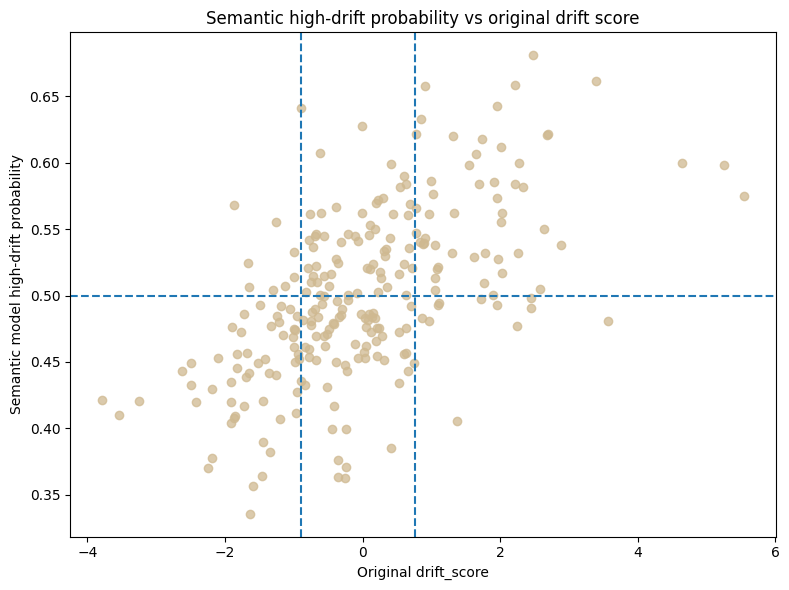

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    features["drift_score"],
    features["semantic_high_drift_probability"],
    alpha=0.75,
    color="#cfb991"
)
plt.axvline(q25, linestyle="--")
plt.axvline(q75, linestyle="--")
plt.axhline(0.5, linestyle="--")
plt.xlabel("Original drift_score")
plt.ylabel("Semantic model high-drift probability")
plt.title("Semantic high-drift probability vs original drift score")
plt.tight_layout()
plt.show()

,phase3_drift_bucket,count,mean,median,std
0,high_drift,62,0.556089,0.548722,0.055835
1,low_drift,62,0.448775,0.449167,0.046535
2,middle,124,0.498399,0.494711,0.052413


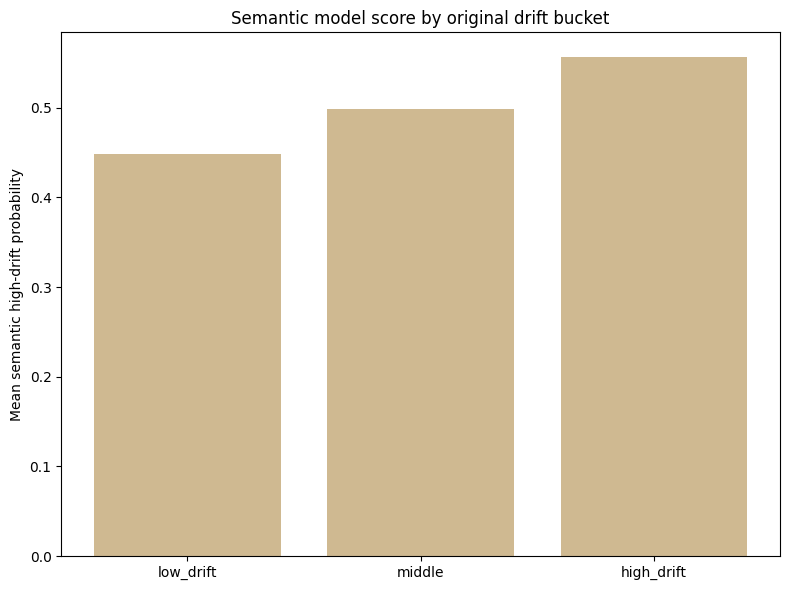

In [ ]:
bucket_summary = (
    features
    .groupby("phase3_drift_bucket")["semantic_high_drift_probability"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(bucket_summary)

ordered = ["low_drift", "middle", "high_drift"]
bucket_summary["phase3_drift_bucket"] = pd.Categorical(
    bucket_summary["phase3_drift_bucket"],
    categories=ordered,
    ordered=True
)
bucket_summary = bucket_summary.sort_values("phase3_drift_bucket")

plt.figure(figsize=(8, 6))
plt.bar(
    bucket_summary["phase3_drift_bucket"].astype(str),
    bucket_summary["mean"],
    color="#cfb991"
)
plt.ylabel("Mean semantic high-drift probability")
plt.title("Semantic model score by original drift bucket")
plt.tight_layout()
plt.show()

In [ ]:
postmortem_files = sorted(POSTMORTEM_DIR.glob("*.txt"))

print("Found postmortems:", len(postmortem_files))
for p in postmortem_files:
    print(p.name)

postmortems = []

for path in postmortem_files:
    text = path.read_text(errors="ignore")

    postmortems.append({
        "postmortem_file": path.name,
        "postmortem_path": str(path),
        "text": text,
        "char_count": len(text),
        "word_count": len(text.split())
    })

postmortem_df = pd.DataFrame(postmortems)

display(postmortem_df[[
    "postmortem_file",
    "char_count",
    "word_count"
]])

Found postmortems: 15
anthropic_2026_claude_code.txt
atlassian_2022_april_outage.txt
aws_s3_2008.txt
azure_storage_2014.txt
cloudflare_2019.txt
discord_connectivity_2017.txt
eve_boot_ini_2007.txt
github_ddos_2018.txt
gitlab_database_2017.txt
heroku_2020_git_push.txt
lkml_leapsecond_futex_2012.txt
mozilla_firefox_2022.txt
roblox_2021.txt
rust_dns_2023.txt
stack_exchange_2014.txt


,postmortem_file,char_count,word_count
0,anthropic_2026_claude_code.txt,10410,1726
1,atlassian_2022_april_outage.txt,49519,7579
2,aws_s3_2008.txt,4977,775
3,azure_storage_2014.txt,7905,1225
4,cloudflare_2019.txt,27478,4634
5,discord_connectivity_2017.txt,10263,1661
6,eve_boot_ini_2007.txt,6440,1090
7,github_ddos_2018.txt,4682,732
8,gitlab_database_2017.txt,23944,3899
9,heroku_2020_git_push.txt,5906,1011


In [ ]:
def split_into_paragraphs(text):
    text = str(text)
    parts = re.split(r"\n\s*\n+", text)
    parts = [p.strip() for p in parts if len(p.strip()) > 40]
    return parts

def make_chunks(text, target_words=180, overlap_words=40):
    paragraphs = split_into_paragraphs(text)

    chunks = []
    current = []
    current_words = 0

    for para in paragraphs:
        words = para.split()

        if current_words + len(words) > target_words and current:
            chunk = " ".join(current).strip()
            chunks.append(chunk)

            overlap = chunk.split()[-overlap_words:]
            current = [" ".join(overlap), para]
            current_words = len(overlap) + len(words)
        else:
            current.append(para)
            current_words += len(words)

    if current:
        chunks.append(" ".join(current).strip())

    return chunks

In [ ]:
postmortem_chunks = []

for _, row in postmortem_df.iterrows():
    chunks = make_chunks(
        row["text"],
        target_words=180,
        overlap_words=40
    )

    for i, chunk in enumerate(chunks):
        postmortem_chunks.append({
            "postmortem_file": row["postmortem_file"],
            "chunk_id": i,
            "chunk_text": chunk,
            "chunk_word_count": len(chunk.split())
        })

postmortem_chunks_df = pd.DataFrame(postmortem_chunks)

print("Postmortem chunks:", postmortem_chunks_df.shape)
display(postmortem_chunks_df.head())

Postmortem chunks: (286, 4)


,postmortem_file,chunk_id,chunk_text,chunk_word_count
0,anthropic_2026_claude_code.txt,0,An update on recent Claude Code quality report...,147
1,anthropic_2026_claude_code.txt,1,less likely to happen again. We take reports a...,270
2,anthropic_2026_claude_code.txt,2,"aggregate effect looked like broad, inconsiste...",124
3,anthropic_2026_claude_code.txt,3,"effort to high. Soon after, we received user f...",143
4,anthropic_2026_claude_code.txt,4,"the product layer, we then choose which point ...",160


In [ ]:
chunk_texts = postmortem_chunks_df["chunk_text"].fillna("").astype(str).tolist()

chunk_embeddings = embedder.encode(
    chunk_texts,
    show_progress_bar=True,
    normalize_embeddings=True,
    batch_size=batch_size
)

postmortem_chunks_df["predicted_high_drift_probability"] = clf.predict_proba(chunk_embeddings)[:, 1]

postmortem_chunks_df["predicted_drift_bucket"] = np.where(
    postmortem_chunks_df["predicted_high_drift_probability"] >= 0.5,
    "likely_high_drift",
    "likely_low_drift"
)

display(
    postmortem_chunks_df
    .sort_values("predicted_high_drift_probability", ascending=False)
    .head(25)
)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

,postmortem_file,chunk_id,chunk_text,chunk_word_count,predicted_high_drift_probability,predicted_drift_bucket
280,rust_dns_2023.txt,4,DNS change. But given the importance of crates...,149,0.593712,likely_high_drift
24,atlassian_2022_april_outage.txt,8,like this in the future? We have taken a numbe...,271,0.564769,likely_high_drift
115,cloudflare_2019.txt,13,the effectiveness of a rule and measure its fa...,139,0.564379,likely_high_drift
202,gitlab_database_2017.txt,33,not being any differences between the source a...,177,0.558187,likely_high_drift
82,atlassian_2022_april_outage.txt,66,against global footprint expansion plans for t...,173,0.556974,likely_high_drift
68,atlassian_2022_april_outage.txt,52,We quickly created a cross-functional team (su...,142,0.555011,likely_high_drift
277,rust_dns_2023.txt,1,of each other. This feature was used to develo...,160,0.553695,likely_high_drift
279,rust_dns_2023.txt,3,the production environment is locked to a spec...,130,0.552635,likely_high_drift
229,mozilla_firefox_2022.txt,11,a staging environment) and deployment. Our set...,133,0.551824,likely_high_drift
269,roblox_2021.txt,38,us to turn up large jobs after a long period o...,111,0.550143,likely_high_drift


In [ ]:
postmortem_drift_summary = (
    postmortem_chunks_df
    .groupby("postmortem_file")
    .agg(
        chunk_count=("chunk_id", "count"),
        mean_high_drift_probability=("predicted_high_drift_probability", "mean"),
        median_high_drift_probability=("predicted_high_drift_probability", "median"),
        max_high_drift_probability=("predicted_high_drift_probability", "max"),
        min_high_drift_probability=("predicted_high_drift_probability", "min"),
        high_drift_chunk_share=("predicted_high_drift_probability", lambda x: (x >= 0.5).mean()),
        severe_drift_chunk_share=("predicted_high_drift_probability", lambda x: (x >= 0.75).mean())
    )
    .reset_index()
)

postmortem_drift_summary["likely_postmortem_drift_level"] = pd.cut(
    postmortem_drift_summary["mean_high_drift_probability"],
    bins=[-0.01, 0.35, 0.65, 1.01],
    labels=["low", "mixed", "high"]
)

postmortem_drift_summary = postmortem_drift_summary.sort_values(
    "mean_high_drift_probability",
    ascending=False
)

display(postmortem_drift_summary)

postmortem_drift_summary.to_csv(
    OUTPUT_DIR / "phase3_postmortem_drift_summary.csv",
    index=False
)

postmortem_chunks_df.to_csv(
    OUTPUT_DIR / "phase3_postmortem_chunk_drift_scores.csv",
    index=False
)

,postmortem_file,chunk_count,mean_high_drift_probability,median_high_drift_probability,max_high_drift_probability,min_high_drift_probability,high_drift_chunk_share,severe_drift_chunk_share,likely_postmortem_drift_level
13,rust_dns_2023.txt,5,0.549237,0.552635,0.593712,0.507937,1.000000,0.0,mixed
0,anthropic_2026_claude_code.txt,16,0.516064,0.519063,0.547435,0.473822,0.750000,0.0,mixed
12,roblox_2021.txt,45,0.504863,0.508976,0.550143,0.439867,0.600000,0.0,mixed
9,heroku_2020_git_push.txt,9,0.502931,0.509661,0.530159,0.471076,0.666667,0.0,mixed
14,stack_exchange_2014.txt,5,0.501841,0.499756,0.539385,0.441748,0.400000,0.0,mixed
1,atlassian_2022_april_outage.txt,68,0.501798,0.501127,0.564769,0.432081,0.514706,0.0,mixed
8,gitlab_database_2017.txt,35,0.500899,0.499263,0.558187,0.450228,0.485714,0.0,mixed
11,mozilla_firefox_2022.txt,13,0.491725,0.489871,0.551824,0.428532,0.307692,0.0,mixed
2,aws_s3_2008.txt,7,0.491705,0.503008,0.525433,0.439851,0.714286,0.0,mixed
6,eve_boot_ini_2007.txt,10,0.482991,0.478174,0.526104,0.445094,0.300000,0.0,mixed


In [ ]:
top_chunks = (
    postmortem_chunks_df
    .sort_values("predicted_high_drift_probability", ascending=False)
    .head(25)
)

for _, row in top_chunks.iterrows():
    print("=" * 120)
    print("FILE:", row["postmortem_file"])
    print("CHUNK:", row["chunk_id"])
    print("HIGH-DRIFT PROBABILITY:", round(row["predicted_high_drift_probability"], 3))
    print()
    print(row["chunk_text"][:1500])
    print()

FILE: rust_dns_2023.txt
CHUNK: 4
HIGH-DRIFT PROBABILITY: 0.594

DNS change. But given the importance of crates.io to the Rust ecosystem, we were hesitant to deploy multiple times without announcing the changes to the community first. The lessons that we are taking away from this incident are as follows: We need to document the process of deploying changes to production, in particular how to pick the Git commit and how to review the changeset. Defining a process will enable us to iterate and improve it over time, and avoid the same issue in the future.
Changes that have been developed and tested in isolation on staging should be deployed individually and in sequence to production. We need to add this to the documentation.
When we merge changes into the main branch, we need to ensure that they get deployed to production as well. This avoids a drift between the configuration in Git and what is deployed.
Get help!

FILE: atlassian_2022_april_outage.txt
CHUNK: 8
HIGH-DRIFT PROBABILITY: 0.56

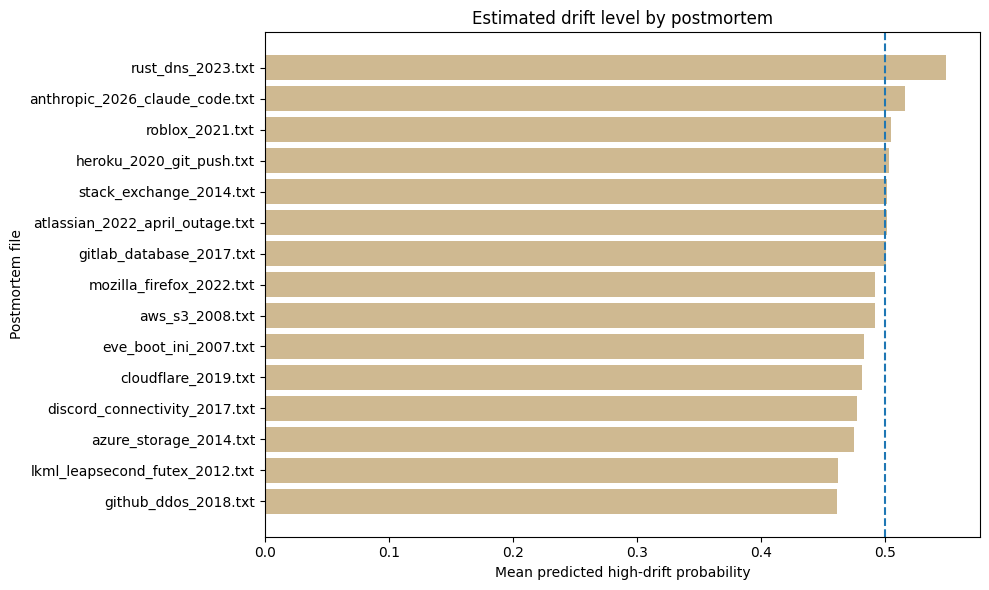

In [ ]:
plot_df = postmortem_drift_summary.sort_values(
    "mean_high_drift_probability",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["postmortem_file"],
    plot_df["mean_high_drift_probability"],
    color="#cfb991"
)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Mean predicted high-drift probability")
plt.ylabel("Postmortem file")
plt.title("Estimated drift level by postmortem")
plt.tight_layout()
plt.show()

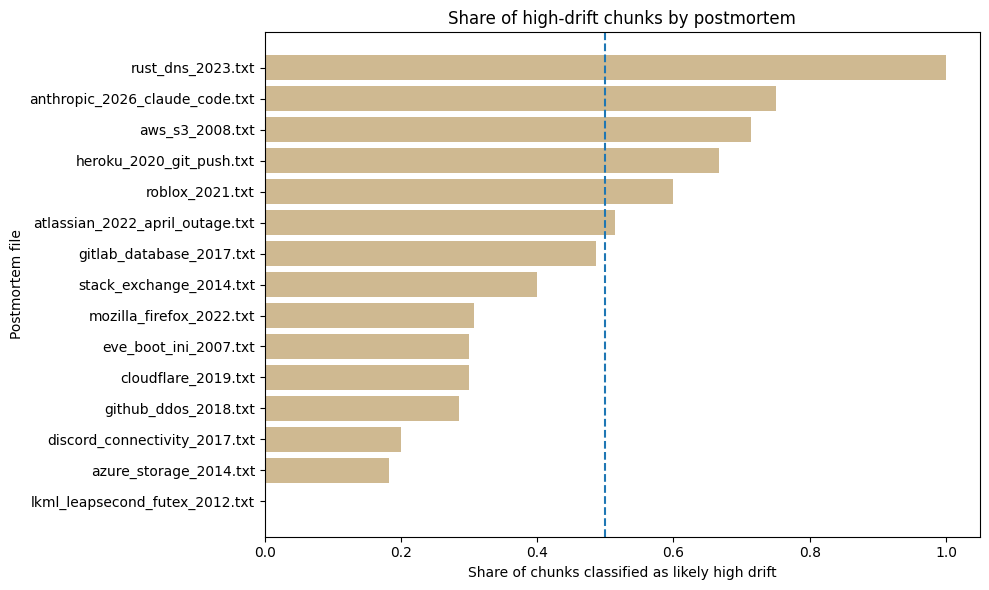

In [ ]:
plot_df = postmortem_drift_summary.sort_values(
    "high_drift_chunk_share",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["postmortem_file"],
    plot_df["high_drift_chunk_share"],
    color="#cfb991"
)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Share of chunks classified as likely high drift")
plt.ylabel("Postmortem file")
plt.title("Share of high-drift chunks by postmortem")
plt.tight_layout()
plt.show()

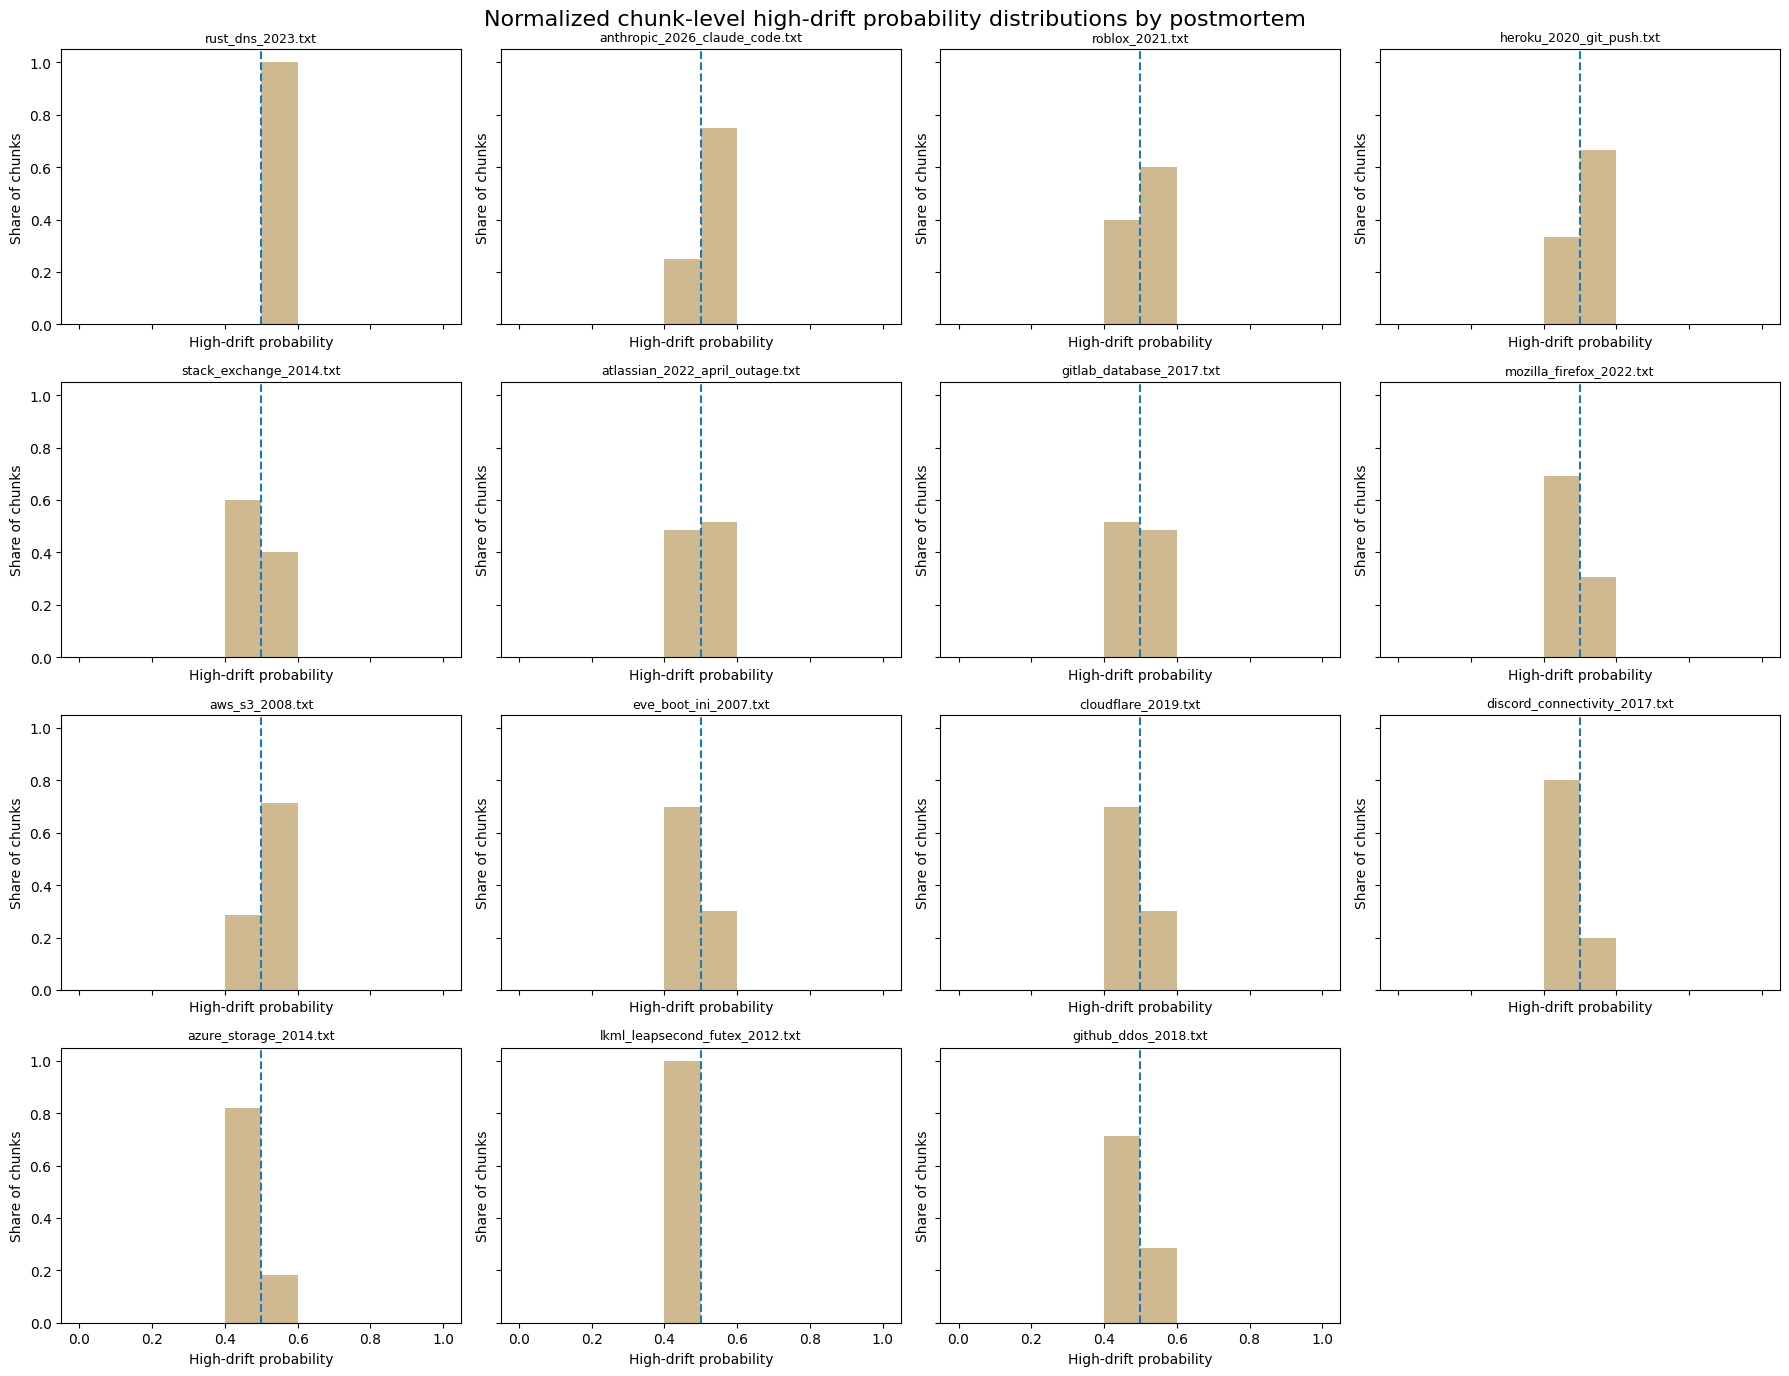

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

files = postmortem_drift_summary["postmortem_file"].tolist()

n_cols = 4
n_rows = 4

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, fname in zip(axes, files):
    temp = postmortem_chunks_df[
        postmortem_chunks_df["postmortem_file"] == fname
    ].copy()

    weights = np.ones(len(temp)) / len(temp)

    ax.hist(
        temp["predicted_high_drift_probability"],
        bins=10,
        range=(0, 1),
        weights=weights,
        color="#cfb991"
    )
    ax.axvline(0.5, linestyle="--")
    ax.set_title(fname, fontsize=9)
    ax.set_xlabel("High-drift probability")
    ax.set_ylabel("Share of chunks")

for ax in axes[len(files):]:
    ax.axis("off")

fig.suptitle(
    "Normalized chunk-level high-drift probability distributions by postmortem",
    fontsize=16
)

plt.tight_layout()
plt.show()


All matched postmortems
N: 15
R²: 0.009
MAE: 0.169
RMSE: 0.196
Pearson r: -0.096 | p=0.733
Spearman rho: -0.126 | p=0.654
Slope: -0.885
Intercept: 1.232

Excluding lkml_leapsecond_futex_2012
N: 14
R²: 0.167
MAE: 0.136
RMSE: 0.154
Pearson r: -0.409 | p=0.147
Spearman rho: -0.362 | p=0.203
Slope: -3.382
Intercept: 2.500


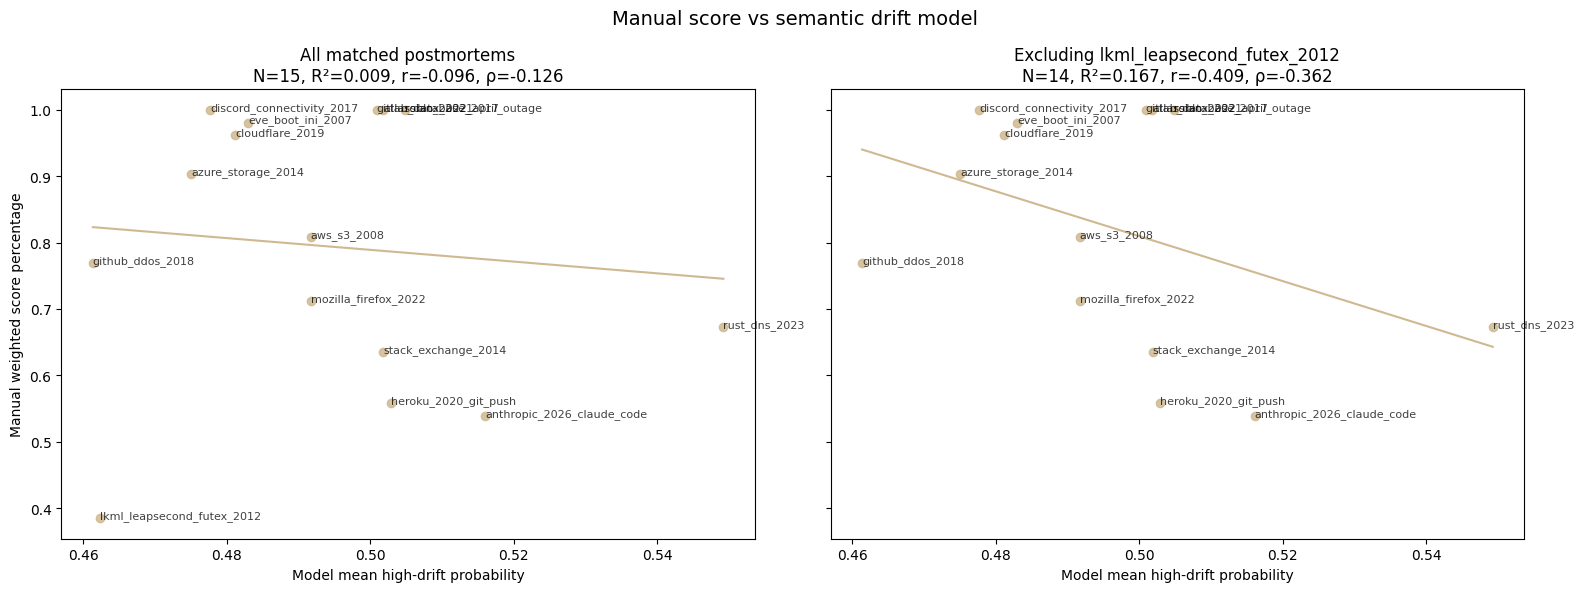


Saved:
/content/drive/MyDrive/postmortem_outputs/phase3_manual_scores_vs_semantic_drift_model_all_matched.csv
/content/drive/MyDrive/postmortem_outputs/phase3_manual_scores_vs_semantic_drift_model_excluding_lkml_leapsecond_futex_2012.csv
/content/drive/MyDrive/postmortem_outputs/phase3_manual_scores_vs_semantic_drift_model_stats_comparison.csv


,label,n,outlier_excluded,r2,mae,rmse,pearson_r,pearson_p,spearman_rho,spearman_p,slope,intercept
0,All matched postmortems,15,None,0.009292,0.168950,0.195911,-0.096397,0.732538,-0.126131,0.65421,-0.885192,1.231665
1,Excluding lkml_leapsecond_futex_2012,14,lkml_leapsecond_futex_2012,0.167000,0.136312,0.154423,-0.408656,0.146851,-0.362245,0.20309,-3.381877,2.500468


In [ ]:
def compute_linear_eval(eval_input_df, label, outlier_merge_id=None):
    x_col = "mean_high_drift_probability"
    y_col = "weighted_pct"

    if outlier_merge_id is not None:
        working_df = eval_input_df[
            eval_input_df["merge_id"] != outlier_merge_id
        ].copy()
    else:
        working_df = eval_input_df.copy()

    plot_df = working_df[[x_col, y_col, "postmortem_file", "merge_id"]].dropna().copy()

    X = plot_df[[x_col]].values
    y = plot_df[y_col].values

    linreg = LinearRegression()
    linreg.fit(X, y)

    plot_df["predicted_manual_score"] = linreg.predict(X)
    plot_df["residual"] = plot_df[y_col] - plot_df["predicted_manual_score"]

    stats = {
        "label": label,
        "n": len(plot_df),
        "outlier_excluded": outlier_merge_id,
        "r2": r2_score(y, plot_df["predicted_manual_score"]),
        "mae": mean_absolute_error(y, plot_df["predicted_manual_score"]),
        "rmse": mean_squared_error(y, plot_df["predicted_manual_score"]) ** 0.5,
        "pearson_r": pearsonr(plot_df[x_col], plot_df[y_col])[0],
        "pearson_p": pearsonr(plot_df[x_col], plot_df[y_col])[1],
        "spearman_rho": spearmanr(plot_df[x_col], plot_df[y_col])[0],
        "spearman_p": spearmanr(plot_df[x_col], plot_df[y_col])[1],
        "slope": linreg.coef_[0],
        "intercept": linreg.intercept_,
    }

    return plot_df, linreg, stats


# Run both evaluations
full_plot_df, full_linreg, full_stats = compute_linear_eval(
    eval_input_df=eval_df,
    label="All matched postmortems",
    outlier_merge_id=None
)

no_outlier_plot_df, no_outlier_linreg, no_outlier_stats = compute_linear_eval(
    eval_input_df=eval_df,
    label="Excluding lkml_leapsecond_futex_2012",
    outlier_merge_id="lkml_leapsecond_futex_2012"
)

# Print both sets of stats
for stats in [full_stats, no_outlier_stats]:
    print("\n" + "=" * 80)
    print(stats["label"])
    print("=" * 80)
    print(f"N: {stats['n']}")
    print(f"R²: {stats['r2']:.3f}")
    print(f"MAE: {stats['mae']:.3f}")
    print(f"RMSE: {stats['rmse']:.3f}")
    print(f"Pearson r: {stats['pearson_r']:.3f} | p={stats['pearson_p']:.3g}")
    print(f"Spearman rho: {stats['spearman_rho']:.3f} | p={stats['spearman_p']:.3g}")
    print(f"Slope: {stats['slope']:.3f}")
    print(f"Intercept: {stats['intercept']:.3f}")


# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_specs = [
    (axes[0], full_plot_df, full_linreg, full_stats),
    (axes[1], no_outlier_plot_df, no_outlier_linreg, no_outlier_stats),
]

x_col = "mean_high_drift_probability"
y_col = "weighted_pct"

for ax, plot_df, linreg, stats in plot_specs:
    ax.scatter(
        plot_df[x_col],
        plot_df[y_col],
        alpha=0.85,
        color="#cfb991"
    )

    x_line = np.linspace(
        plot_df[x_col].min(),
        plot_df[x_col].max(),
        100
    )

    y_line = linreg.predict(x_line.reshape(-1, 1))

    ax.plot(x_line, y_line, color="#cfb991")

    for _, row in plot_df.iterrows():
        label_text = row["postmortem_file"].replace(".txt", "")
        ax.annotate(
            label_text,
            (row[x_col], row[y_col]),
            fontsize=8,
            alpha=0.75
        )

    ax.set_xlabel("Model mean high-drift probability")
    ax.set_title(
        f"{stats['label']}\n"
        f"N={stats['n']}, R²={stats['r2']:.3f}, "
        f"r={stats['pearson_r']:.3f}, ρ={stats['spearman_rho']:.3f}"
    )

axes[0].set_ylabel("Manual weighted score percentage")

fig.suptitle("Manual score vs semantic drift model", fontsize=14)
fig.tight_layout()
plt.show()


# Save both evaluation outputs
full_eval_out = eval_df.merge(
    full_plot_df[["postmortem_file", "predicted_manual_score", "residual"]],
    on="postmortem_file",
    how="left"
)

no_outlier_eval_out = eval_df[
    eval_df["merge_id"] != "lkml_leapsecond_futex_2012"
].merge(
    no_outlier_plot_df[["postmortem_file", "predicted_manual_score", "residual"]],
    on="postmortem_file",
    how="left"
)

FULL_SAVE_PATH = OUTPUT_DIR / "phase3_manual_scores_vs_semantic_drift_model_all_matched.csv"
NO_OUTLIER_SAVE_PATH = OUTPUT_DIR / "phase3_manual_scores_vs_semantic_drift_model_excluding_lkml_leapsecond_futex_2012.csv"
STATS_SAVE_PATH = OUTPUT_DIR / "phase3_manual_scores_vs_semantic_drift_model_stats_comparison.csv"

full_eval_out.to_csv(FULL_SAVE_PATH, index=False)
no_outlier_eval_out.to_csv(NO_OUTLIER_SAVE_PATH, index=False)

stats_df = pd.DataFrame([full_stats, no_outlier_stats])
stats_df.to_csv(STATS_SAVE_PATH, index=False)

print("\nSaved:")
print(FULL_SAVE_PATH)
print(NO_OUTLIER_SAVE_PATH)
print(STATS_SAVE_PATH)

display(stats_df)